Generating hypergraph...
Generated hyperedges m = 2000
Running MMCA...
MMCA done in 0.19s


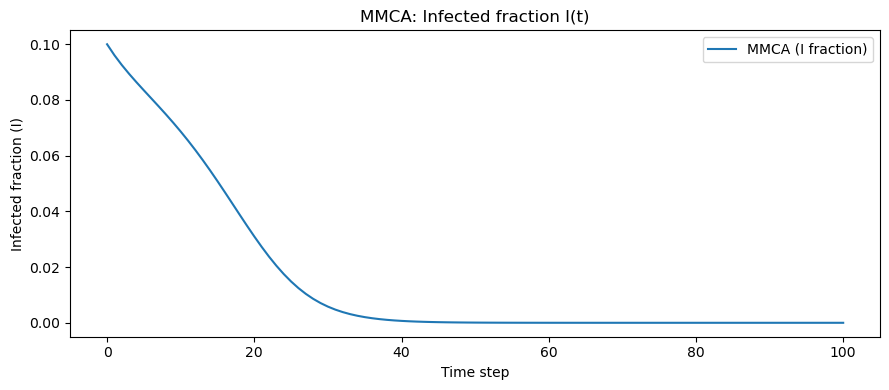

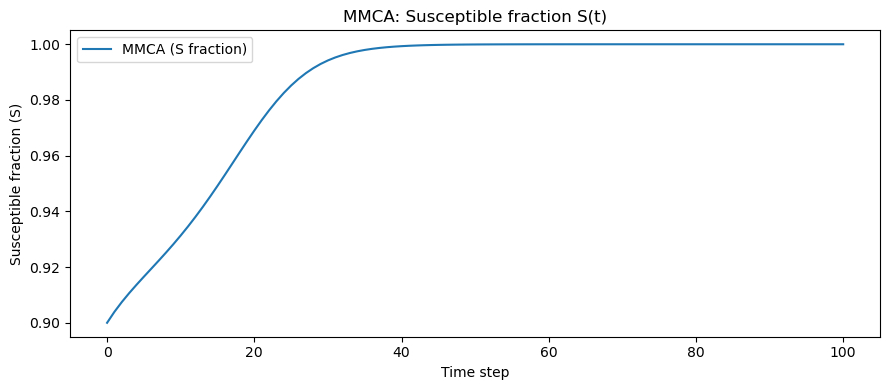

Final infected (MMCA): 0.0000


In [1]:

"""
生成 3-uniform 超图并运行 MMCA（确定性），绘制 I(t) 和 S(t)。
运行方式：python hyper_mmca_plot.py
"""

import numpy as np
import random
import math
import matplotlib.pyplot as plt
from time import time

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0]
        self.edge_j = self.hyperedges[:,1]
        self.edge_k = self.hyperedges[:,2]

        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def compute_qi(self, p, Theta, beta_d):
        prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
        qi = np.zeros(self.n, dtype=float)
        for node in range(self.n):
            prod_val = 1.0
            for (ei, pos) in self.node_edge_pos[node]:
                if pos == 0:
                    prod_oth = prod_pos0[ei]
                elif pos == 1:
                    prod_oth = prod_pos1[ei]
                else:
                    prod_oth = prod_pos2[ei]
                prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
            qi[node] = 1.0 - prod_val
        return np.clip(qi, 0.0, 1.0)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        return np.clip(Theta_new, 0.0, 1.0)

    def run_mmca(self, beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                 T=100, init_frac=0.01, verbose=False):
        p = np.full(self.n, init_frac, dtype=float)
        Theta = np.ones(self.m, dtype=float)
        rho_ts = []
        theta_ts = []
        for t in range(T):
            rho_ts.append(p.mean())
            theta_ts.append(Theta.mean())
            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)
            Q = np.ones(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val
            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta = self._update_theta_from_p(p, Theta, eta, gamma)
            p = p_next
            if verbose and (t % 20 == 0):
                print(f"[MMCA] t={t:3d}  rho={rho_ts[-1]:.4f}  ⟨Θ⟩={theta_ts[-1]:.4f}")
        rho_ts.append(p.mean()); theta_ts.append(Theta.mean())
        return np.array(rho_ts), np.array(theta_ts)


# -------------------- 参数（可修改） --------------------
n = 1000
kappa = 6.0
beta = 0.3
mu = 0.2
T = 100
init_frac = 0.1
seed = 12345
eta = 0.5
gamma = 0.3

print("Generating hypergraph...")
hyperedges = generate_hypergraph_H_n_m_3(n=n, kappa=kappa, seed=seed, batch_size=3000)
print("Generated hyperedges m =", hyperedges.shape[0])

model = HyperSISModel(hyperedges, n)

print("Running MMCA...")
t0 = time()
rho_mmca, theta_mmca = model.run_mmca(beta_d=beta, mu=mu, eta=eta, gamma=gamma,
                                        T=T, init_frac=init_frac, verbose=False)
t_mmca = time() - t0
print(f"MMCA done in {t_mmca:.2f}s")

ts = np.arange(T+1)

# 绘图：I(t)
plt.figure(figsize=(9,4))
plt.plot(ts, rho_mmca, label='MMCA (I fraction)')
plt.xlabel("Time step")
plt.ylabel("Infected fraction (I)")
plt.title("MMCA: Infected fraction I(t)")
plt.legend()
plt.tight_layout()
plt.show()

# 绘图：S(t)
S_mmca = 1.0 - rho_mmca
plt.figure(figsize=(9,4))
plt.plot(ts, S_mmca, label='MMCA (S fraction)')
plt.xlabel("Time step")
plt.ylabel("Susceptible fraction (S)")
plt.title("MMCA: Susceptible fraction S(t)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final infected (MMCA): {rho_mmca[-1]:.4f}")
